# Porto → Casablanca GPS Remapping
Full pipeline with memory-optimized SparkSession

In [1]:
import sys
print(sys.executable)
import pyspark
print('PySpark version:', pyspark.__version__)

c:\Users\dell\Desktop\big data project\TaaSim-Project\.venv-1\Scripts\python.exe
PySpark version: 3.5.0


## 1. Start SparkSession with enough memory

In [2]:
from pyspark.sql import SparkSession
from pyspark import SparkContext
import os

# Force-clean stale Spark/Py4J state (fixes ConnectionRefusedError after JVM crash)
try:
    if 'spark' in globals() and spark is not None:
        spark.stop()
except Exception:
    pass

SparkSession._instantiatedSession = None
SparkSession._activeSession = None
SparkContext._active_spark_context = None
SparkContext._gateway = None
SparkContext._jvm = None

# Windows Hadoop fix (required when using S3A packages on local Spark)
hadoop_home = os.path.abspath(os.path.join(os.path.expanduser("~"), "hadoop"))
hadoop_home_posix = hadoop_home.replace("\\", "/")
hadoop_bin = os.path.join(hadoop_home, "bin")
os.environ["HADOOP_HOME"] = hadoop_home
os.environ["PATH"] = hadoop_bin + os.pathsep + os.environ.get("PATH", "")
os.environ["SPARK_SUBMIT_OPTS"] = f"-Dhadoop.home.dir={hadoop_home_posix}"

# Spark session configured for MinIO (S3A)
spark = SparkSession.builder \
    .appName("PortoCasaRemap") \
    .master("local[*]") \
    .config("spark.driver.memory", "4g") \
    .config("spark.driver.host", "127.0.0.1") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.jars.packages", "org.apache.hadoop:hadoop-aws:3.3.4,com.amazonaws:aws-java-sdk-bundle:1.12.262") \
    .config("spark.hadoop.fs.s3a.endpoint", "http://localhost:9000") \
    .config("spark.hadoop.fs.s3a.access.key", "minioadmin") \
    .config("spark.hadoop.fs.s3a.secret.key", "minioadmin123") \
    .config("spark.hadoop.fs.s3a.path.style.access", "true") \
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
    .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false") \
    .config("spark.hadoop.fs.s3a.aws.credentials.provider", "org.apache.hadoop.fs.s3a.SimpleAWSCredentialsProvider") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("HADOOP_HOME:", os.environ.get("HADOOP_HOME"))
print("Spark version:", spark.version)

HADOOP_HOME: C:\Users\dell\hadoop
Spark version: 3.5.0


## 2. Load the dataset

In [2]:
input_path = "s3a://raw/porto-trips/"
df = spark.read.csv(input_path, header=True, inferSchema=True)
print("Input path:", input_path)
print("Row count:", df.count())
df.printSchema()

Input path: s3a://raw/porto-trips/
Row count: 1710670
root
 |-- TRIP_ID: long (nullable = true)
 |-- CALL_TYPE: string (nullable = true)
 |-- ORIGIN_CALL: integer (nullable = true)
 |-- ORIGIN_STAND: integer (nullable = true)
 |-- TAXI_ID: integer (nullable = true)
 |-- TIMESTAMP: integer (nullable = true)
 |-- DAY_TYPE: string (nullable = true)
 |-- MISSING_DATA: boolean (nullable = true)
 |-- POLYLINE: string (nullable = true)



In [3]:
df.select('TRIP_ID', 'POLYLINE').show(5, truncate=False)

+-------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 3. Parse POLYLINE column into array of coordinates

In [4]:
from pyspark.sql.functions import from_json, col, lit, when, explode, collect_list, struct
from pyspark.sql.types import ArrayType, DoubleType

polyline_schema = ArrayType(ArrayType(DoubleType()))

df = df.withColumn(
    'coords',
    from_json(col('POLYLINE'), polyline_schema)
)

df.select('TRIP_ID', 'coords').show(3, truncate=False)

+-------------------+-------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 4. Filter bad rows early (reduces memory pressure)

In [15]:
import csv
import os
import subprocess
import sys

project_root = os.getcwd()
if not os.path.isdir(os.path.join(project_root, 'data')):
    project_root = os.path.abspath(os.path.join(project_root, '..'))

# Keep zone mapping in sync with scripts/generate_zone_mapping.py
generate_script = os.path.join(project_root, 'scripts', 'generate_zone_mapping.py')
subprocess.check_call([sys.executable, generate_script], cwd=project_root)

zone_path = os.path.join(project_root, 'data', 'zone_mapping.csv')
centroids = []
with open(zone_path, 'r', encoding='utf-8') as f:
    for row in csv.DictReader(f):
        centroids.append((float(row['centroid_lon']), float(row['centroid_lat'])))

PORTO_LON_MIN, PORTO_LON_MAX = -8.690, -8.550
PORTO_LAT_MIN, PORTO_LAT_MAX = 41.100, 41.190

CASA_LON_MIN = min(lon for lon, _ in centroids)
CASA_LON_MAX = max(lon for lon, _ in centroids)
CASA_LAT_MIN = min(lat for _, lat in centroids) - 0.002
CASA_LAT_MAX = max(lat for _, lat in centroids) + 0.002

print('Zone mapping regenerated from script:', zone_path)

Zone mapping regenerated from script: c:\Users\dell\Desktop\big data project\TaaSim-Project\data\zone_mapping.csv


## 5. Explode coordinates into separate rows

In [17]:
df = df.withColumn('coord', explode(col('coords'))) \
       .withColumn('porto_lon', col('coord')[0]) \
       .withColumn('porto_lat', col('coord')[1])

df.select('TRIP_ID', 'porto_lon', 'porto_lat').show(5)

+-------------------+---------+---------+
|            TRIP_ID|porto_lon|porto_lat|
+-------------------+---------+---------+
|1372636858620000589|-8.618643|41.141412|
|1372636858620000589|-8.618499|41.141376|
|1372636858620000589|-8.620326| 41.14251|
|1372636858620000589|-8.622153|41.143815|
|1372636858620000589|-8.623953|41.144373|
+-------------------+---------+---------+
only showing top 5 rows



## 6. Define bounding boxes for Porto and Casablanca

In [18]:
PORTO_LON_MIN, PORTO_LON_MAX = -8.690, -8.550
PORTO_LAT_MIN, PORTO_LAT_MAX =  41.100, 41.190

CASA_LON_MIN,  CASA_LON_MAX  = -7.680, -7.520
CASA_LAT_MIN,  CASA_LAT_MAX  =  33.470, 33.600

## 7. Clamp Porto coordinates to bounding box

In [19]:
porto_lon_clamped = when(col('porto_lon') < PORTO_LON_MIN, PORTO_LON_MIN) \
    .when(col('porto_lon') > PORTO_LON_MAX, PORTO_LON_MAX) \
    .otherwise(col('porto_lon'))

porto_lat_clamped = when(col('porto_lat') < PORTO_LAT_MIN, PORTO_LAT_MIN) \
    .when(col('porto_lat') > PORTO_LAT_MAX, PORTO_LAT_MAX) \
    .otherwise(col('porto_lat'))

## 8. Remap Porto GPS → Casablanca GPS (linear interpolation)

In [20]:
df = df.withColumn(
    'casa_lon',
    lit(CASA_LON_MIN) +
    ((porto_lon_clamped - lit(PORTO_LON_MIN)) / lit(PORTO_LON_MAX - PORTO_LON_MIN)) *
    lit(CASA_LON_MAX - CASA_LON_MIN)
).withColumn(
    'casa_lat',
    lit(CASA_LAT_MIN) +
    ((porto_lat_clamped - lit(PORTO_LAT_MIN)) / lit(PORTO_LAT_MAX - PORTO_LAT_MIN)) *
    lit(CASA_LAT_MAX - CASA_LAT_MIN)
)

df.select('TRIP_ID', 'porto_lon', 'porto_lat', 'casa_lon', 'casa_lat').show(5)

+-------------------+---------+---------+------------------+------------------+
|            TRIP_ID|porto_lon|porto_lat|          casa_lon|          casa_lat|
+-------------------+---------+---------+------------------+------------------+
|1372636858620000589|-8.618643|41.141412|-7.598449142857143| 33.52981733333334|
|1372636858620000589|-8.618499|41.141376|-7.598284571428571| 33.52976533333334|
|1372636858620000589|-8.620326| 41.14251|-7.600372571428571| 33.53140333333334|
|1372636858620000589|-8.622153|41.143815|-7.602460571428572| 33.53328833333333|
|1372636858620000589|-8.623953|41.144373|-7.604517714285714|33.534094333333336|
+-------------------+---------+---------+------------------+------------------+
only showing top 5 rows



## 9. Group coordinates back by trip (memory-safe — sampled)

In [6]:
from pyspark.sql.functions import collect_list, struct, from_json, col, lit, when, explode
from pyspark.sql.types import ArrayType, DoubleType

# Make this cell resilient to out-of-order execution.
if 'coords' not in df.columns:
    polyline_schema = ArrayType(ArrayType(DoubleType()))
    df = df.withColumn('coords', from_json(col('POLYLINE'), polyline_schema))

if 'porto_lon' not in df.columns or 'porto_lat' not in df.columns:
    df = df.withColumn('coord', explode(col('coords'))) \
           .withColumn('porto_lon', col('coord')[0]) \
           .withColumn('porto_lat', col('coord')[1])

if 'casa_lon' not in df.columns or 'casa_lat' not in df.columns:
    porto_lon_min = globals().get('PORTO_LON_MIN', -8.690)
    porto_lon_max = globals().get('PORTO_LON_MAX', -8.550)
    porto_lat_min = globals().get('PORTO_LAT_MIN', 41.100)
    porto_lat_max = globals().get('PORTO_LAT_MAX', 41.190)

    casa_lon_min = globals().get('CASA_LON_MIN', -7.680)
    casa_lon_max = globals().get('CASA_LON_MAX', -7.520)
    casa_lat_min = globals().get('CASA_LAT_MIN', 33.470)
    casa_lat_max = globals().get('CASA_LAT_MAX', 33.600)

    porto_lon_clamped = when(col('porto_lon') < porto_lon_min, lit(porto_lon_min)) \
        .when(col('porto_lon') > porto_lon_max, lit(porto_lon_max)) \
        .otherwise(col('porto_lon'))

    porto_lat_clamped = when(col('porto_lat') < porto_lat_min, lit(porto_lat_min)) \
        .when(col('porto_lat') > porto_lat_max, lit(porto_lat_max)) \
        .otherwise(col('porto_lat'))

    df = df.withColumn(
        'casa_lon',
        lit(casa_lon_min) +
        ((porto_lon_clamped - lit(porto_lon_min)) / lit(porto_lon_max - porto_lon_min)) *
        lit(casa_lon_max - casa_lon_min)
    ).withColumn(
        'casa_lat',
        lit(casa_lat_min) +
        ((porto_lat_clamped - lit(porto_lat_min)) / lit(porto_lat_max - porto_lat_min)) *
        lit(casa_lat_max - casa_lat_min)
    )

# Sample to avoid OOM on collect_list - adjust fraction as needed.
# Use fraction=1.0 only if your machine has enough RAM (16GB+)
df_sampled = df.sample(fraction=0.3, seed=42)

trips = df_sampled.groupBy('TRIP_ID') \
    .agg(collect_list(struct('casa_lat', 'casa_lon')).alias('waypoints'))

trips.show(4, truncate=False)

+-------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|TRIP_ID            |waypoints                                                                                                                                                                                                                                                                                                                                   |
+-------------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

## 10. Verify remapping with a scatter plot

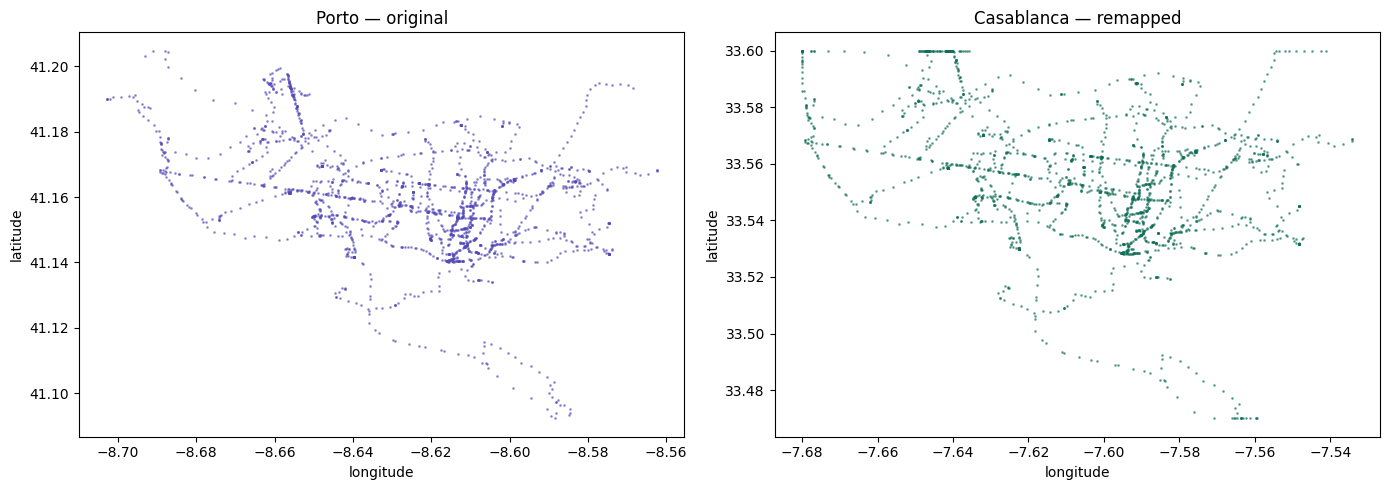

In [7]:
import matplotlib.pyplot as plt

porto_sample = df.select('porto_lon', 'porto_lat').limit(2000).toPandas()
casa_sample  = df.select('casa_lon',  'casa_lat' ).limit(2000).toPandas()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(porto_sample['porto_lon'], porto_sample['porto_lat'],
                s=1, color='#534AB7', alpha=0.5)
axes[0].set_title('Porto — original')
axes[0].set_xlabel('longitude')
axes[0].set_ylabel('latitude')

axes[1].scatter(casa_sample['casa_lon'], casa_sample['casa_lat'],
                s=1, color='#0F6E56', alpha=0.5)
axes[1].set_title('Casablanca — remapped')
axes[1].set_xlabel('longitude')
axes[1].set_ylabel('latitude')

plt.tight_layout()
plt.savefig('remap_verify.png', dpi=150)
plt.show()

## 11. Interactive map with Folium

In [8]:
import folium
import random

# Collect only 50 trips to avoid memory issues
sample_trips = trips.limit(500).toPandas()

# Map centered on Casablanca
m = folium.Map(location=[33.57, -7.60], zoom_start=12)

def random_color():
    return '#{:06x}'.format(random.randint(0, 0xFFFFFF))

for _, row in sample_trips.iterrows():
    # FIX: use 'waypoints' (was 'waypoint' — typo in original)
    coords = [(p['casa_lat'], p['casa_lon']) for p in row['waypoints']]
    if len(coords) < 2:
        continue  # skip trips with only one point
    folium.PolyLine(
        coords,
        color=random_color(),
        weight=2,
        opacity=0.7
    ).add_to(m)

m.save('../data/casa_remap_trips_map.html')
print('Map saved to ../data/casa_remap_trips_map.html')
m

Map saved to ../data/casa_remap_trips_map.html
